In [2]:
import numpy as np
X = np.array(([2, 9], [1, 5], [3, 6]), dtype=float)
y = np.array(([92], [86], [89]), dtype=float)
X = X/np.amax(X,axis=0) # maximum of X array longitudinally
y = y/100
#Sigmoid Function
def sigmoid (x):
    return (1/(1 + np.exp(-x)))
#Derivative of Sigmoid Function
def derivatives_sigmoid(x):
    return x * (1 - x)
#Variable initialization
epoch=7000 #Setting training iterations
lr=0.1 #Setting learning rate
inputlayer_neurons = 2 #number of features in data set
hiddenlayer_neurons = 3 #number of hidden layers neurons
output_neurons = 1 #number of neurons at output layer
#weight and bias initialization
wh=np.random.uniform(size=(inputlayer_neurons,hiddenlayer_neurons))
bh=np.random.uniform(size=(1,hiddenlayer_neurons))
wout=np.random.uniform(size=(hiddenlayer_neurons,output_neurons))
bout=np.random.uniform(size=(1,output_neurons))
# draws a random range of numbers uniformly of dim x*y #Forward Propagation
for i in range(epoch):
    hinp1=np.dot(X,wh)
    hinp=hinp1 + bh
    hlayer_act = sigmoid(hinp)
    outinp1=np.dot(hlayer_act,wout)
    outinp= outinp1+ bout
    output = sigmoid(outinp)
#Backpropagation
EO = y-output
outgrad = derivatives_sigmoid(output)
d_output = EO* outgrad
EH = d_output.dot(wout.T)
hiddengrad = derivatives_sigmoid(hlayer_act) #how much hidden layer wts contributed to error
d_hiddenlayer = EH * hiddengrad
wout += hlayer_act.T.dot(d_output) *lr
# dotproduct of nextlayererror and currentlayerop
bout += np.sum(d_output, axis=0,keepdims=True) *lr
wh += X.T.dot(d_hiddenlayer) *lr
#bh += np.sum(d_hiddenlayer, axis=0,keepdims=True) *lr
print("Input: \n" + str(X))
print("Actual Output: \n" + str(y))
print("Predicted Output: \n" ,output)

Input: 
[[0.66666667 1.        ]
 [0.33333333 0.55555556]
 [1.         0.66666667]]
Actual Output: 
[[0.92]
 [0.86]
 [0.89]]
Predicted Output: 
 [[0.70965866]
 [0.70204174]
 [0.70826279]]


In [8]:
import csv, random, math

def loadCsv(filename):
    with open(filename, "r") as f:
        lines = csv.reader(f)
        dataset = list(lines)
    # Skip header if first element is not a number
    try:
        float(dataset[0][0])
    except (ValueError, IndexError):
        dataset = dataset[1:]
    for i in range(len(dataset)):
        dataset[i] = [float(x) for x in dataset[i]]
    return dataset

def splitDataset(dataset, splitRatio):
    trainSize = int(len(dataset) * splitRatio)
    trainSet = []
    copy = list(dataset)
    while len(trainSet) < trainSize:
        index = random.randrange(len(copy))
        trainSet.append(copy.pop(index))
    return [trainSet, copy]

def separateByClass(dataset):
    separated = {}
    for i in range(len(dataset)):
        vector = dataset[i]
        if (vector[-1] not in separated):
            separated[vector[-1]] = []
        separated[vector[-1]].append(vector)
    return separated

def mean(numbers):
    return sum(numbers)/float(len(numbers))

def stdev(numbers):
    avg = mean(numbers)
    if len(numbers) <= 1:
        return 0.0
    variance = sum([pow(x-avg,2) for x in numbers])/float(len(numbers)-1)
    return math.sqrt(variance)

def summarize(dataset):
    summaries = [(mean(attribute), stdev(attribute)) for attribute in zip(*dataset)]
    del summaries[-1]
    return summaries

def summarizeByClass(dataset):
    separated = separateByClass(dataset)
    summaries = {}
    for classValue, instances in separated.items():
        summaries[classValue] = summarize(instances)
    return summaries

def calculateProbability(x, mean, stdev):
    if stdev == 0:
        return 1.0 if x == mean else 0.0
    exponent = math.exp(-(math.pow(x-mean,2)/(2*math.pow(stdev,2))))
    return (1 / (math.sqrt(2*math.pi) * stdev)) * exponent

def calculateClassProbabilities(summaries, inputVector):
    probabilities = {}
    for classValue, classSummaries in summaries.items():
        probabilities[classValue] = 1
        for i in range(len(classSummaries)):
            mean, stdev = classSummaries[i]
            x = inputVector[i]
            probabilities[classValue] *= calculateProbability(x, mean, stdev)
    return probabilities

def predict(summaries, inputVector):
    probabilities = calculateClassProbabilities(summaries, inputVector)
    bestLabel, bestProb = None, -1
    for classValue, probability in probabilities.items():
        if bestLabel is None or probability > bestProb:
            bestProb = probability
            bestLabel = classValue
    return bestLabel

def getPredictions(summaries, testSet):
    predictions = []
    for i in range(len(testSet)):
        result = predict(summaries, testSet[i])
        predictions.append(result)
    return predictions

def getAccuracy(testSet, predictions):
    correct = 0
    for i in range(len(testSet)):
        if testSet[i][-1] == predictions[i]:
            correct += 1
    return (correct/float(len(testSet))) * 100.0

def main():
    filename = "/BankNoteAuthentication.csv"
    splitRatio = 0.67
    dataset = loadCsv(filename)
    trainingSet, testSet = splitDataset(dataset, splitRatio)
    print(f"Split {len(dataset)} rows into train={len(trainingSet)} and test={len(testSet)} rows")
    # prepare model
    summaries = summarizeByClass(trainingSet)
    # test model
    predictions = getPredictions(summaries, testSet)
    accuracy = getAccuracy(testSet, predictions)
    print(f"Accuracy: {accuracy}%")

main()

Split 1372 rows into train=919 and test=453 rows
Accuracy: 83.00220750551877%


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

# Load the dataset (using the file we just created)
msg = pd.read_csv('naivetext1.csv', names=['message', 'label'])
print('The dimensions of the dataset', msg.shape)

# Map labels to numerical values
msg['labelnum'] = msg.label.map({'pos': 1, 'neg': 0})
X = msg.message
y = msg.labelnum

# Split the dataset
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=42)
print('Test shape:', xtest.shape)
print('Train shape:', xtrain.shape)

# Vectorize the text data
count_vect = CountVectorizer()
xtrain_dtm = count_vect.fit_transform(xtrain)
xtest_dtm = count_vect.transform(xtest)

# Train the classifier
clf = MultinomialNB().fit(xtrain_dtm, ytrain)
predicted = clf.predict(xtest_dtm)

# Accuracy metrics
print('\nAccuracy metrics')
print('Accuracy of the classifier is', metrics.accuracy_score(ytest, predicted))
print('Confusion matrix:\n', metrics.confusion_matrix(ytest, predicted))
print('Recall:', metrics.recall_score(ytest, predicted))
print('Precision:', metrics.precision_score(ytest, predicted))

The dimensions of the dataset (10, 2)
Test shape: (3,)
Train shape: (7,)

Accuracy metrics
Accuracy of the classifier is 0.3333333333333333
Confusion matrix:
 [[0 2]
 [0 1]]
Recall: 1.0
Precision: 0.3333333333333333


In [11]:
import pandas as pd

# Creating the missing 'naivetext1.csv' file with sample data
data = [
    ['I love this sandwich', 'pos'],
    ['This is an amazing place', 'pos'],
    ['I feel very good about these beers', 'pos'],
    ['This is my best work', 'pos'],
    ['What an awesome view', 'pos'],
    ['I do not like this restaurant', 'neg'],
    ['I am tired of this stuff', 'neg'],
    ['I cannot deal with this', 'neg'],
    ['He is my sworn enemy', 'neg'],
    ['My boss is horrible', 'neg']
]

df_sample = pd.DataFrame(data, columns=['message', 'label'])
df_sample.to_csv('naivetext1.csv', index=False, header=False)
print('File naivetext1.csv created successfully.')

File naivetext1.csv created successfully.


In [20]:
import numpy as np
from urllib.request import urlopen
import urllib
import pandas as pd
from pgmpy.inference import VariableElimination
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator

# Note: This code requires 'heart.csv' to be present in the environment.
names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'heartdisease']
try:
    heartDisease = pd.read_csv('heart.csv', names=names)
    heartDisease = heartDisease.replace('?', np.nan)

    # Using DiscreteBayesianNetwork as BayesianNetwork is deprecated
    model = DiscreteBayesianNetwork([
        ('age', 'trestbps'),
        ('age', 'fbs'),
        ('sex', 'trestbps'),
        ('exang', 'trestbps'),
        ('trestbps', 'heartdisease'),
        ('fbs', 'heartdisease'),
        ('heartdisease', 'restecg'),
        ('heartdisease', 'thalach'),
        ('heartdisease', 'chol')
    ])

    model.fit(heartDisease, estimator=MaximumLikelihoodEstimator)

    HeartDisease_infer = VariableElimination(model)
    q = HeartDisease_infer.query(variables=['heartdisease'], evidence={'age': 37, 'sex': 0})
    print(q)
except FileNotFoundError:
    print("Error: 'heart.csv' file not found. Please ensure the dataset is uploaded to the directory.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

+-----------------+---------------------+
| heartdisease    |   phi(heartdisease) |
+=================+=====================+
| heartdisease(0) |              0.8775 |
+-----------------+---------------------+
| heartdisease(1) |              0.1225 |
+-----------------+---------------------+


In [18]:
import pandas as pd
import numpy as np

# Defining the columns required by the Bayesian Network model
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'heartdisease']

# Generating synthetic data
data = {
    'age': np.random.randint(29, 77, size=100),
    'sex': np.random.randint(0, 2, size=100),
    'cp': np.random.randint(0, 4, size=100),
    'trestbps': np.random.randint(94, 200, size=100),
    'chol': np.random.randint(126, 564, size=100),
    'fbs': np.random.randint(0, 2, size=100),
    'restecg': np.random.randint(0, 3, size=100),
    'thalach': np.random.randint(71, 202, size=100),
    'exang': np.random.randint(0, 2, size=100),
    'oldpeak': np.random.uniform(0, 6.2, size=100),
    'slope': np.random.randint(0, 3, size=100),
    'ca': np.random.randint(0, 5, size=100),
    'thal': np.random.randint(0, 4, size=100),
    'heartdisease': np.random.randint(0, 2, size=100)
}

df_heart = pd.DataFrame(data)
# Save to CSV without header to match the read_csv(names=names) logic in the existing cell
df_heart.to_csv('heart.csv', index=False, header=False)
print('Synthetic heart.csv created successfully.')
display(df_heart.head())

Synthetic heart.csv created successfully.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,heartdisease
0,64,1,2,96,274,0,2,148,0,0.170903,2,4,3,1
1,43,0,0,104,523,0,2,198,0,3.793358,0,0,0,0
2,71,0,2,96,242,1,0,162,0,4.379847,2,3,0,0
3,62,0,1,121,278,1,1,117,0,3.189876,2,1,2,0
4,44,1,1,111,465,0,0,111,1,0.912148,2,2,1,0


In [15]:
!pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 10.4 MB/s eta 0:00:00



EM predictions:
 [0 0 0 2 1 2 1 2 0 2 2 2 0 2 1 0 0 2 2 2 2 1 1 1 0 0 0 0 2 1 0 2 2 2 2 2 2
 2 0 2 1 2 0 1 1 2 0 2 1 0]
Means:
 [[61.06680361 36.22272696]
 [73.76844104 16.54102267]
 [27.53445456 21.74823998]]

Covariances:
 [[[103.02752104  25.41098675]
  [ 25.41098675  31.80820102]]

 [[160.59373793  39.4611857 ]
  [ 39.4611857   36.3659889 ]]

 [[ 94.17999001  17.79976644]
  [ 17.79976644 136.74847581]]]

K-Means Centers:
 [[26.5        19.68181818]
 [54.5625     34.75      ]
 [77.33333333 21.91666667]]
K-Means Labels:
 [1 2 1 1 2 0 2 0 1 0 0 0 1 0 2 1 1 0 0 0 0 2 2 1 1 1 1 1 0 0 1 0 0 0 0 1 0
 0 1 0 2 0 1 2 2 0 2 0 2 2]


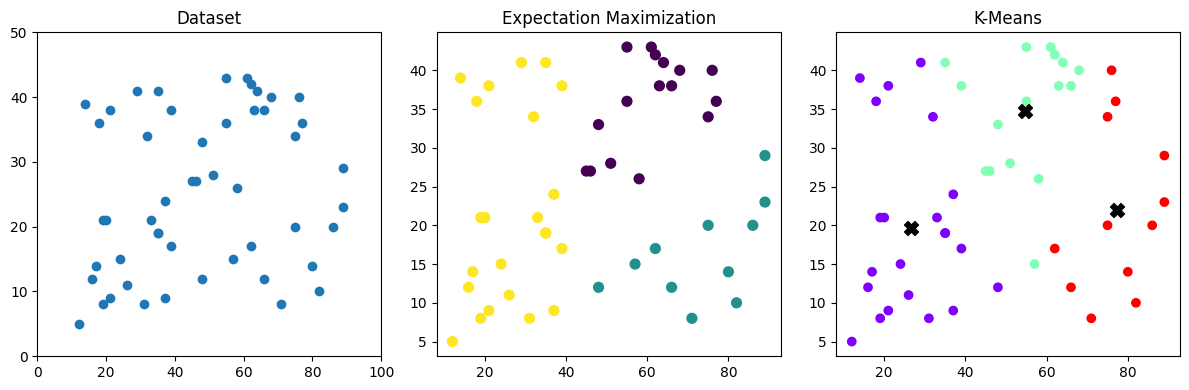

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# --- Create synthetic data to replace missing 'kmeansdata.csv' ---
data = {
    'Distance_Feature': np.random.randint(10, 90, size=50),
    'Speeding_Feature': np.random.randint(5, 45, size=50)
}
df = pd.DataFrame(data)
df.to_csv('kmeansdata.csv', index=False)

# --- Load and Process Data ---
X_df = pd.read_csv("kmeansdata.csv")
x1 = X_df['Distance_Feature'].values
x2 = X_df['Speeding_Feature'].values
X = np.array(list(zip(x1, x2)))

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.xlim([0, 100])
plt.ylim([0, 50])
plt.title('Dataset')
plt.scatter(x1, x2)

# --- EM Algorithm ---
gmm = GaussianMixture(n_components=3)
gmm.fit(X)
em_predictions = gmm.predict(X)

print("\nEM predictions:\n", em_predictions)
print("Means:\n", gmm.means_)
print("\nCovariances:\n", gmm.covariances_)

plt.subplot(132)
plt.title('Expectation Maximization')
plt.scatter(X[:,0], X[:,1], c=em_predictions, s=50, cmap='viridis')

# --- K-Means Algorithm ---
kmeans = KMeans(n_clusters=3, n_init=10)
kmeans.fit(X)

print("\nK-Means Centers:\n", kmeans.cluster_centers_)
print("K-Means Labels:\n", kmeans.labels_)

plt.subplot(133)
plt.title('K-Means')
plt.scatter(X[:,0], X[:,1], c=kmeans.labels_, cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color='black', marker='X', s=100)
plt.tight_layout()
plt.show()

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import pandas as pd

# Loading the Iris dataset from sklearn instead of a missing CSV file
iris = load_iris()
X = iris.data
y = iris.target

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.25)

# Initializing the classifier
classifier = KNeighborsClassifier(n_neighbors=8, p=3, metric='euclidean')
classifier.fit(X_train, y_train)

# Predicting the test results
y_pred = classifier.predict(X_test)

# Accuracy metrics
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix is as follows:\n', cm)
print('\nAccuracy Metrics:')
print(classification_report(y_test, y_pred))
print("Correct prediction:", accuracy_score(y_test, y_pred))
print("Wrong prediction:", (1 - accuracy_score(y_test, y_pred)))

Confusion matrix is as follows:
 [[13  0  0]
 [ 0 15  1]
 [ 0  0  9]]

Accuracy Metrics:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.94      0.97        16
           2       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38

Correct prediction: 0.9736842105263158
Wrong prediction: 0.02631578947368418


In [26]:
import numpy as np
from bokeh.plotting import figure, show, output_notebook
from bokeh.layouts import gridplot
from bokeh.io import push_notebook

output_notebook()

def local_regression(x0, X, Y, tau):
    # add bias term
    x0_with_bias = np.r_[1, x0]
    X_with_bias = np.c_[np.ones(len(X)), X]
    # fit model: normal equations with kernel
    xw = X_with_bias.T * radial_kernel(x0_with_bias, X_with_bias, tau)
    beta = np.linalg.pinv(xw @ X_with_bias) @ xw @ Y
    # predict value
    return x0_with_bias @ beta

def radial_kernel(x0, X, tau):
    return np.exp(np.sum((X - x0) ** 2, axis=1) / (-2 * tau * tau))

n = 1000
# generate dataset
X = np.linspace(-3, 3, num=n)
Y = np.log(np.abs(X ** 2 - 1) + .5)
# jitter X
X += np.random.normal(scale=.1, size=n)
domain = np.linspace(-3, 3, num=300)

def plot_lwr(tau):
    # prediction through regression
    prediction = [local_regression(x0, X, Y, tau) for x0 in domain]
    plot = figure(width=400, height=400)
    plot.title.text = 'tau=%g' % tau
    plot.scatter(X, Y, alpha=.3)
    plot.line(domain, prediction, line_width=2, color='red')
    return plot

# Plotting the curves with different tau values
show(gridplot([
    [plot_lwr(10.0), plot_lwr(1.0)],
    [plot_lwr(0.1), plot_lwr(0.01)]
]))